# Module 2 — Borrower Churn Prediction

**Business Question:** Which borrowers will NOT take a second loan within 12 months of repaying their first?

**Task Type:** Binary Classification
- Target: `churn_flag` → 0 = returned (took second loan within 12 months), 1 = churned (did not return)

**Why this module is unique:**
The churn label does not exist in the raw data — we engineer it ourselves from borrower history.
This demonstrates analytical thinking beyond just running models.

**Models compared:**
1. Logistic Regression (baseline)
2. Random Forest
3. XGBoost (champion)

**Pipeline:**
```
Load processed data → Engineer churn label → Feature selection →
Train/test split → Train 3 models → Evaluate → Feature importance
```

## 1. Import Libraries

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
os.chdir(r'C:\Users\User\Documents\finsight-forecasting')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# Model saving
import joblib

print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2. Load Processed Data

In [2]:
df = pd.read_csv('data/processed/loans_cleaned.csv', low_memory=False)
print(f'Dataset shape: {df.shape}')

# Parse issue_d back to datetime
df['issue_d'] = pd.to_datetime(df['issue_d'], errors='coerce')

print(f'Date range: {df["issue_d"].min()} → {df["issue_d"].max()}')
df.head(3)

Dataset shape: (1344936, 96)
Date range: 2007-06-01 00:00:00 → 2018-12-01 00:00:00


,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,default_flag,issue_year,issue_month
0,68407277,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,...,178050.0,7746.0,2400.0,13734.0,N,Cash,N,0,2015,12
1,68355089,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,...,314017.0,39475.0,79300.0,24667.0,N,Cash,N,0,2015,12
2,68341763,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,...,218418.0,18696.0,6200.0,14877.0,N,Cash,N,0,2015,12


In [4]:
print(df.columns.tolist())

['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct

## 3. Engineer Churn Label

**Logic:**
- Group loans by `member_id`
- Sort by `issue_d` (loan date)
- For each loan, check if the same borrower took another loan within 12 months
- If yes → `churn_flag = 0` (retained)
- If no → `churn_flag = 1` (churned)

We only look at borrowers who have **fully paid** their loan,
because only they had the opportunity to return.

In [5]:
# No member_id available — using early repayment behaviour as churn proxy
# Logic:
# Paid off early = strong financial health = more likely to return = churn_flag = 0
# Paid on full term = average customer = more likely to churn = churn_flag = 1

df_paid = df[df['loan_status'] == 'Fully Paid'].copy()
print(f'Fully paid loans: {len(df_paid):,}')

# Calculate actual repayment duration in months
df_paid['last_pymnt_d'] = pd.to_datetime(df_paid['last_pymnt_d'], errors='coerce')
df_paid['issue_d']      = pd.to_datetime(df_paid['issue_d'], errors='coerce')

df_paid['actual_months'] = (
    (df_paid['last_pymnt_d'].dt.year  - df_paid['issue_d'].dt.year) * 12 +
    (df_paid['last_pymnt_d'].dt.month - df_paid['issue_d'].dt.month)
)

# Extract loan term as integer ("36 months" → 36)
df_paid['term_months'] = df_paid['term'].str.extract(r'(\d+)').astype(float)

# Churn = 1 if borrower took 85% or more of the full loan term to repay
df_paid['churn_flag'] = (
    df_paid['actual_months'] >= df_paid['term_months'] * 0.85
).astype(int)

print(f'\nChurn flag distribution:')
print(df_paid['churn_flag'].value_counts())
print(f'\nChurn rate: {df_paid["churn_flag"].mean():.2%}')

Fully paid loans: 1,076,448

Churn flag distribution:
churn_flag
0    769335
1    307113
Name: count, dtype: int64

Churn rate: 28.53%


## 4. Feature Selection

In [6]:
FEATURES = [
    'loan_amnt',       # loan amount
    'int_rate',        # interest rate
    'installment',     # monthly payment
    'annual_inc',      # annual income
    'dti',             # debt-to-income ratio
    'emp_length',      # employment length
    'home_ownership',  # renter / owner / mortgage
    'purpose',         # reason for loan
    'grade',           # loan grade
    'open_acc',        # open credit lines
    'total_acc',       # total credit lines
    'revol_util',      # revolving utilization
    'delinq_2yrs',     # delinquencies in 2 years
    'issue_year',      # year of loan
    'issue_month',     # month of loan
]

TARGET = 'churn_flag'

df_model = df_paid[FEATURES + [TARGET]].copy()
print(f'Model dataset shape: {df_model.shape}')
print(f'\nNull values:')
print(df_model.isnull().sum())

Model dataset shape: (1076448, 16)

Null values:
loan_amnt             0
int_rate              0
installment           0
annual_inc            0
dti                   0
emp_length        57092
home_ownership        0
purpose               0
grade                 0
open_acc              0
total_acc             0
revol_util          676
delinq_2yrs           0
issue_year            0
issue_month           0
churn_flag            0
dtype: int64


## 5. Feature Engineering

In [7]:
# Encode categorical columns
cat_cols = ['home_ownership', 'purpose', 'grade']
le = LabelEncoder()

for col in cat_cols:
    df_model[col] = df_model[col].astype(str)
    df_model[col] = le.fit_transform(df_model[col])

# Fill nulls with median
df_model = df_model.fillna(df_model.median(numeric_only=True))

print('Encoding complete.')
print(f'Null values remaining: {df_model.isnull().sum().sum()}')

Encoding complete.
Null values remaining: 0


## 6. Train / Test Split

In [8]:
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')
print(f'Churn rate in train: {y_train.mean():.2%}')
print(f'Churn rate in test:  {y_test.mean():.2%}')

Training set: (861158, 15)
Test set:     (215290, 15)
Churn rate in train: 28.53%
Churn rate in test:  28.53%


## 7. Train Models

Note: We do NOT use SMOTE here because churn data is typically
not as imbalanced as default data. We use `class_weight='balanced'`
instead — a simpler and often equally effective approach.

In [9]:
# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# --- Model 1: Logistic Regression ---
print('Training Logistic Regression...')
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr.fit(X_train_scaled, y_train)
print('Done.')

Training Logistic Regression...
Done.


In [10]:
# --- Model 2: Random Forest ---
print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print('Done.')

Training Random Forest...
Done.


In [11]:
# --- Model 3: XGBoost ---
print('Training XGBoost...')

# Calculate scale_pos_weight to handle imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f'scale_pos_weight: {scale:.2f}')

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
print('Done.')

Training XGBoost...
scale_pos_weight: 2.51
Done.


## 8. Evaluate Models

In [12]:
def evaluate_model(name, model, X_test, y_test, scaled=False, threshold=0.5):
    X_input = X_test_scaled if scaled else X_test
    y_prob  = model.predict_proba(X_input)[:, 1]
    y_pred  = (y_prob >= threshold).astype(int)
    auc     = roc_auc_score(y_test, y_prob)

    print(f'\n{"-"*50}')
    print(f'Model: {name}  |  Threshold: {threshold}')
    print(f'AUC-ROC: {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))
    return auc

auc_lr  = evaluate_model('Logistic Regression', lr,  X_test, y_test, scaled=True)
auc_rf  = evaluate_model('Random Forest',       rf,  X_test, y_test)
auc_xgb = evaluate_model('XGBoost',             xgb, X_test, y_test)


--------------------------------------------------
Model: Logistic Regression  |  Threshold: 0.5
AUC-ROC: 0.7823
              precision    recall  f1-score   support

    Retained       0.88      0.68      0.77    153867
     Churned       0.49      0.76      0.59     61423

    accuracy                           0.70    215290
   macro avg       0.68      0.72      0.68    215290
weighted avg       0.76      0.70      0.72    215290


--------------------------------------------------
Model: Random Forest  |  Threshold: 0.5
AUC-ROC: 0.7906
              precision    recall  f1-score   support

    Retained       0.92      0.59      0.72    153867
     Churned       0.46      0.88      0.60     61423

    accuracy                           0.67    215290
   macro avg       0.69      0.73      0.66    215290
weighted avg       0.79      0.67      0.69    215290


--------------------------------------------------
Model: XGBoost  |  Threshold: 0.5
AUC-ROC: 0.8139
              precisio

## 9. ROC Curve Comparison

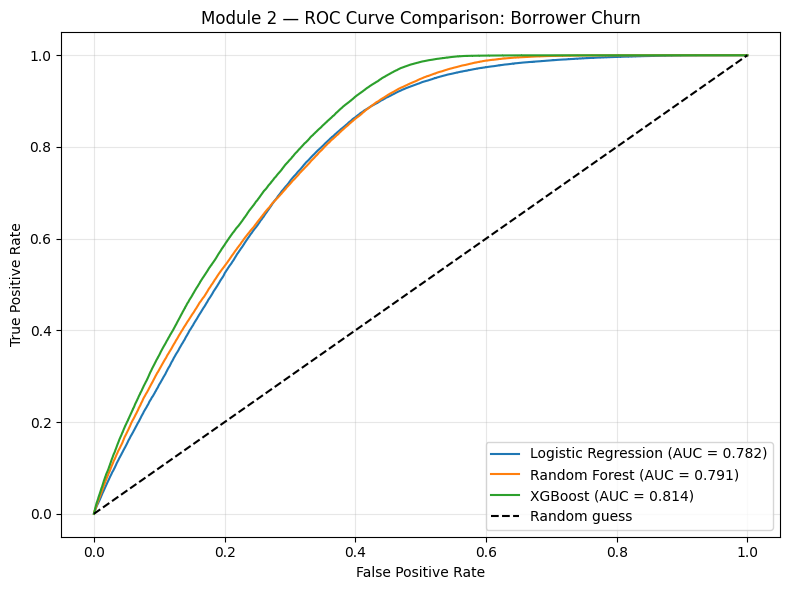

ROC curve saved to reports/


In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model, scaled in [
    ('Logistic Regression', lr,  True),
    ('Random Forest',       rf,  False),
    ('XGBoost',             xgb, False),
]:
    X_input = X_test_scaled if scaled else X_test
    y_prob  = model.predict_proba(X_input)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Module 2 — ROC Curve Comparison: Borrower Churn')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('reports/module2_roc_curve.png', dpi=150)
plt.show()
print('ROC curve saved to reports/')

## 10. Confusion Matrix — XGBoost

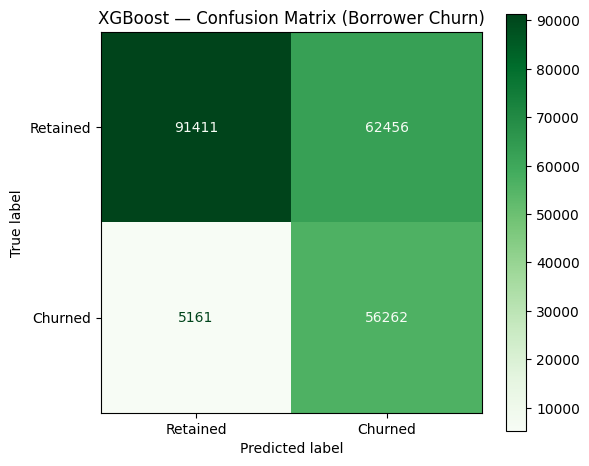

In [14]:
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=['Retained', 'Churned'],
    cmap='Greens',
    ax=ax
)
ax.set_title('XGBoost — Confusion Matrix (Borrower Churn)')
plt.tight_layout()
plt.savefig('reports/module2_confusion_matrix.png', dpi=150)
plt.show()

## 11. Feature Importance — XGBoost

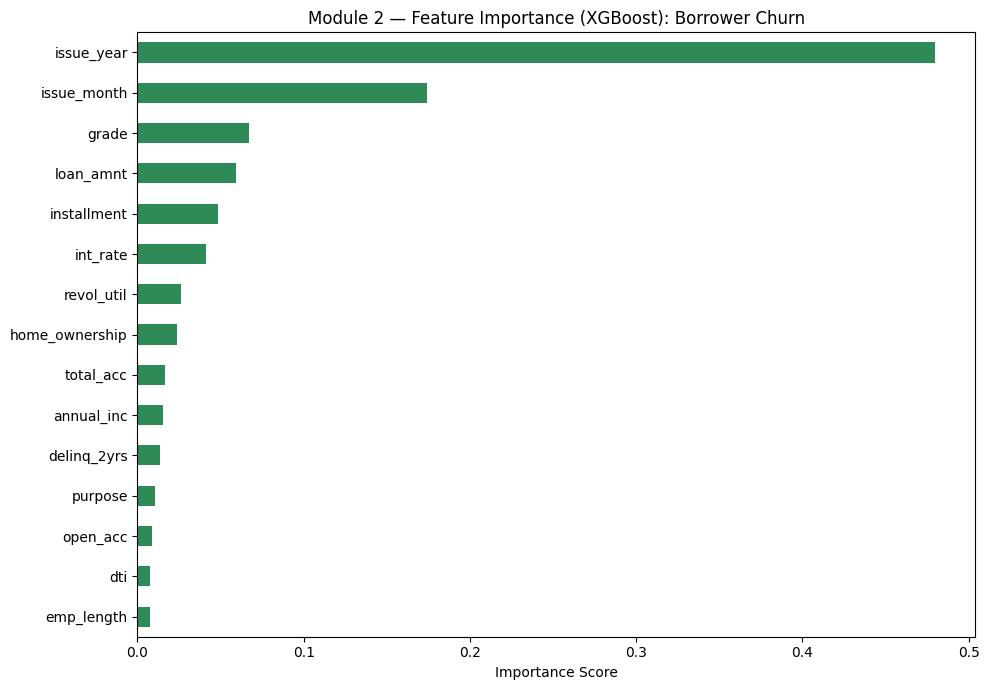

Feature importance plot saved to reports/


In [15]:
feat_imp = pd.Series(
    xgb.feature_importances_,
    index=X_test.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
feat_imp.plot(kind='barh', color='seagreen')
plt.title('Module 2 — Feature Importance (XGBoost): Borrower Churn')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('reports/module2_feature_importance.png', dpi=150)
plt.show()
print('Feature importance plot saved to reports/')

## 12. Model Comparison Summary

In [16]:
results = pd.DataFrame({
    'Model':   ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'AUC-ROC': [round(auc_lr, 4), round(auc_rf, 4), round(auc_xgb, 4)]
})

results = results.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
results.index += 1
print('Module 2 — Model Comparison')
print(results.to_string())

Module 2 — Model Comparison
                 Model  AUC-ROC
1              XGBoost   0.8139
2        Random Forest   0.7906
3  Logistic Regression   0.7823


## 13. Save Models

In [17]:
joblib.dump(xgb,      'models/module2_xgb.pkl')
joblib.dump(rf,       'models/module2_rf.pkl')
joblib.dump(lr,       'models/module2_lr.pkl')
joblib.dump(scaler,   'models/module2_scaler.pkl')
joblib.dump(FEATURES, 'models/module2_features.pkl')

print('All Module 2 models saved to models/')

All Module 2 models saved to models/
